In [64]:
import pandas as pd 
import numpy as np

In [65]:
df = pd.read_csv("C:\\Users\\user\\Desktop\\end to end ML project\\notebook\\data\\stud.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [66]:
df.shape

(1000, 8)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [68]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [69]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [70]:
df.duplicated().sum()

0

In [71]:
df.corr(numeric_only=True)

,math_score,reading_score,writing_score
math_score,1.000000,0.817580,0.802642
reading_score,0.817580,1.000000,0.954598
writing_score,0.802642,0.954598,1.000000


# EDA

### Univariate Analysis

In [72]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(exclude='object').columns

##### Categorical cols analysis

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

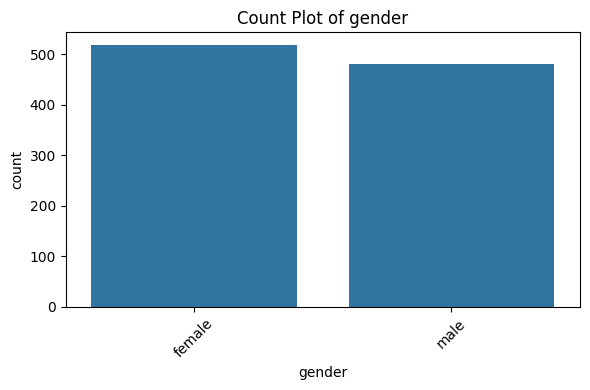

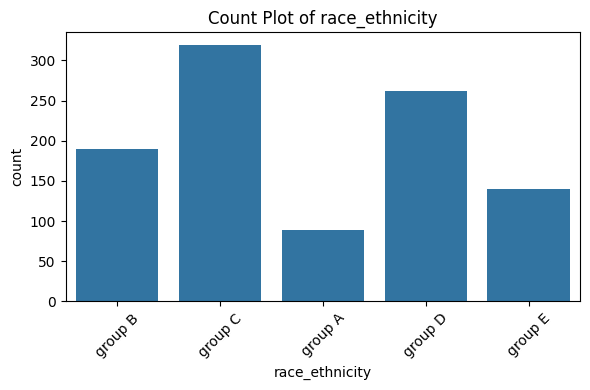

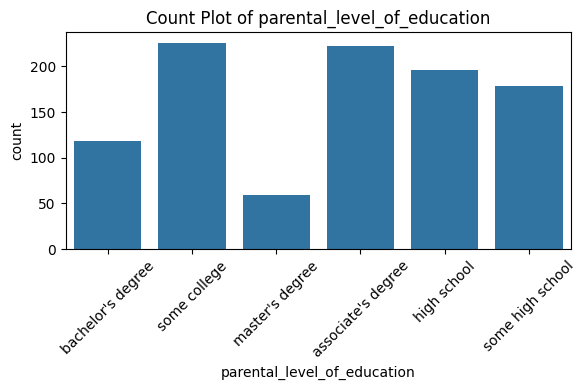

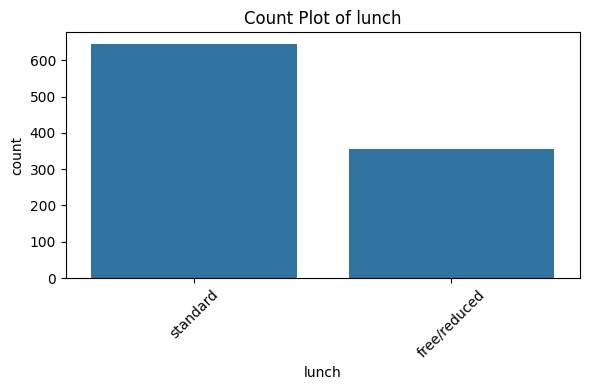

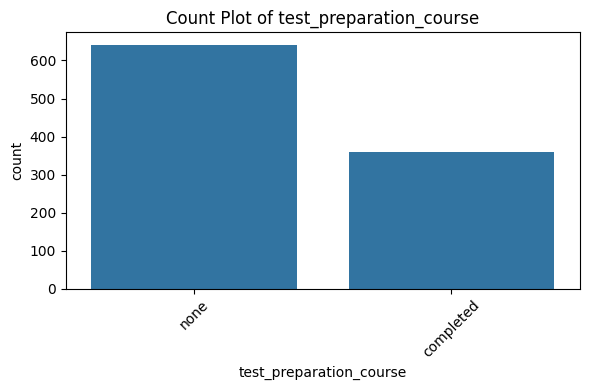

In [74]:
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

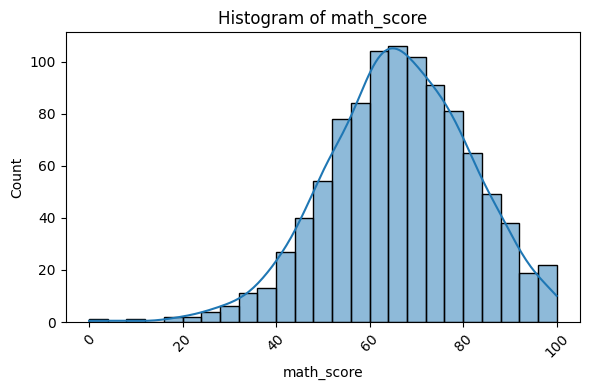

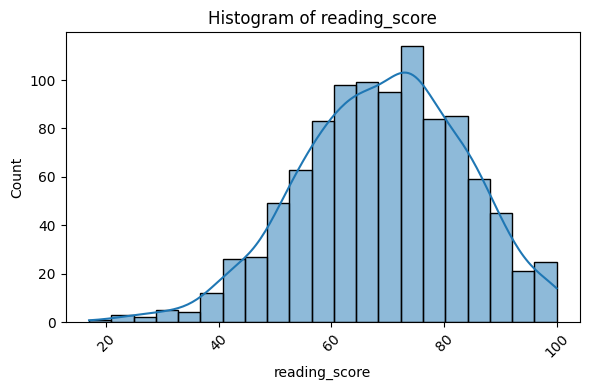

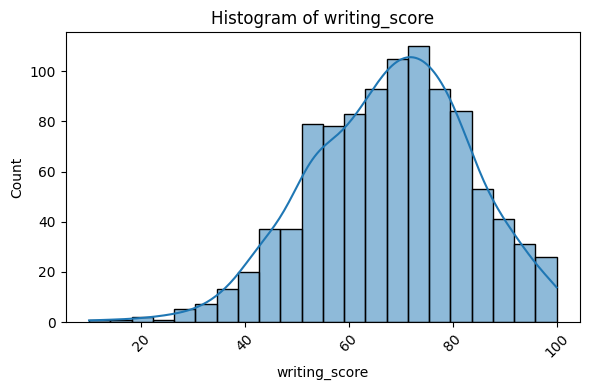

In [75]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

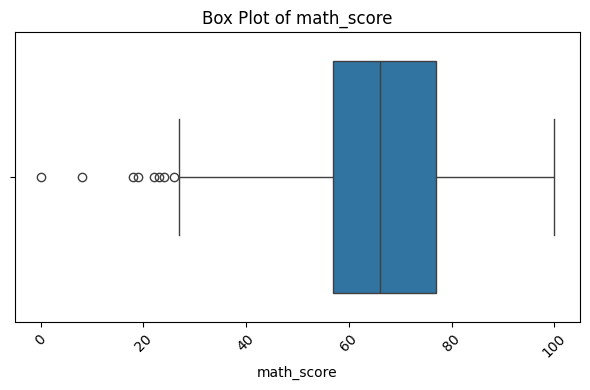

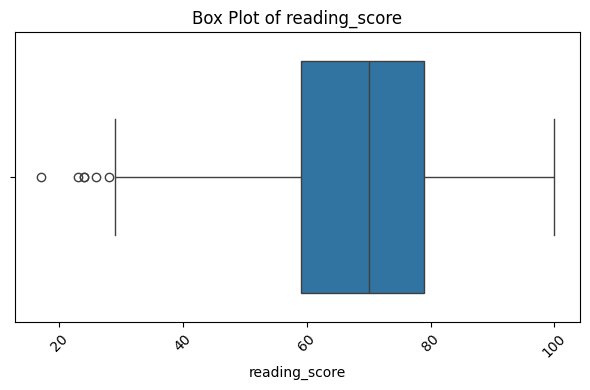

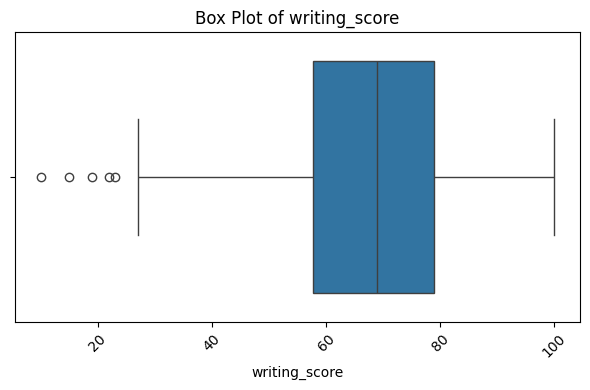

In [76]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Box Plot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

##### Bivariate analysis

In [77]:
list(numerical_cols).remove('writing_score')

In [78]:
numerical_cols

Index(['math_score', 'reading_score', 'writing_score'], dtype='object')

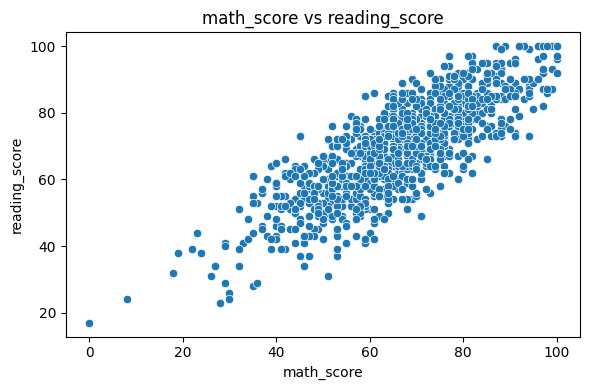

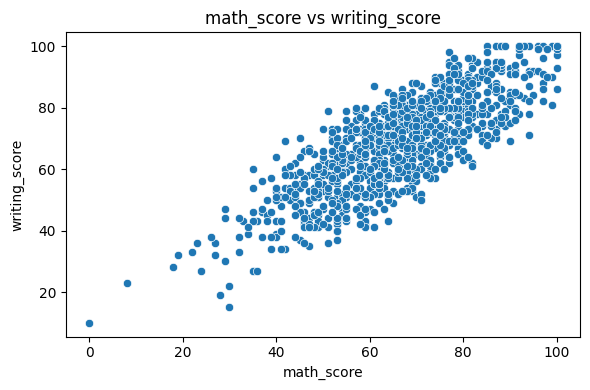

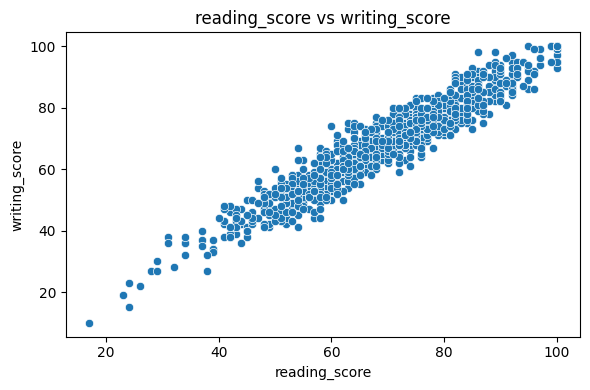

In [79]:
from itertools import combinations

# Scatter plots
for x, y in combinations(numerical_cols, 2):
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=x, y=y)
    plt.title(f"{x} vs {y}")
    plt.tight_layout()
    plt.show()

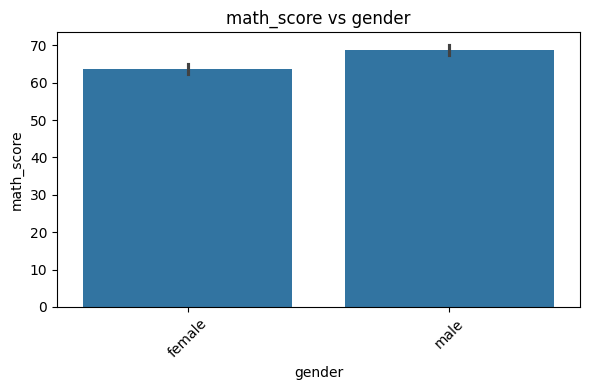

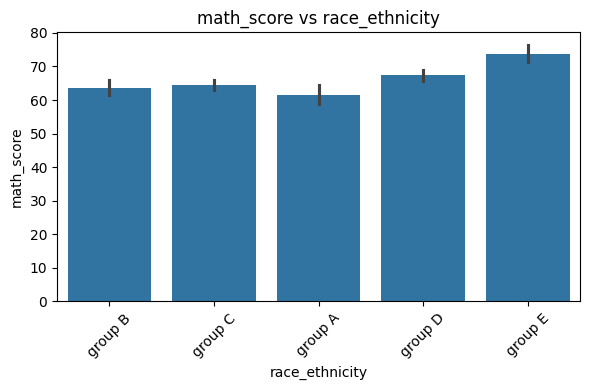

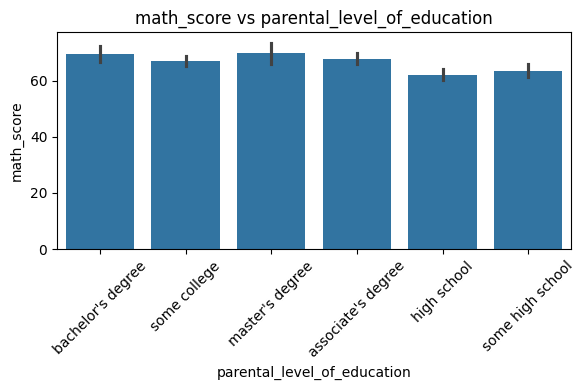

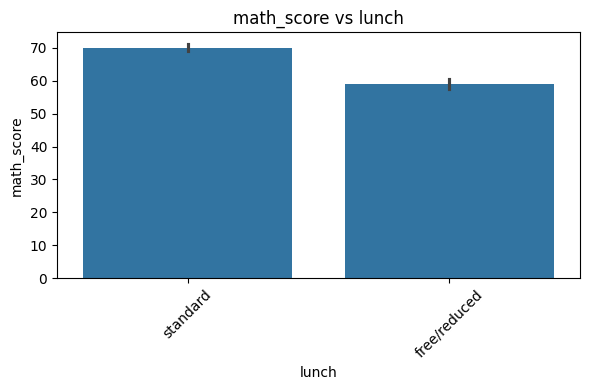

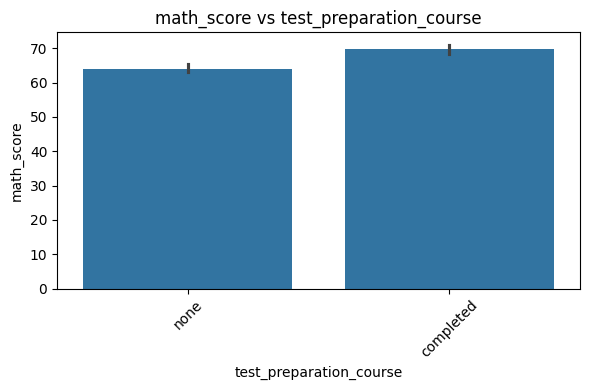

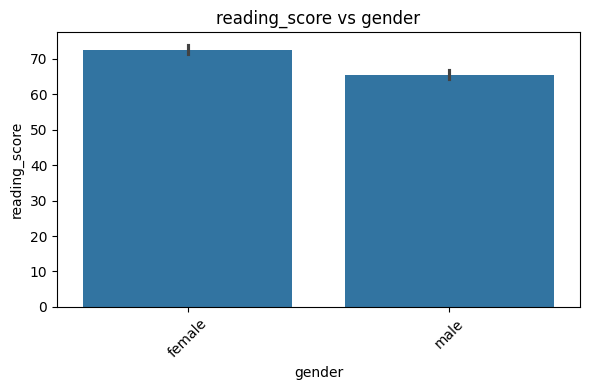

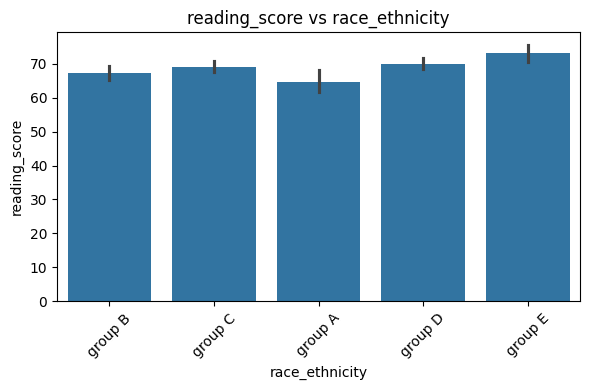

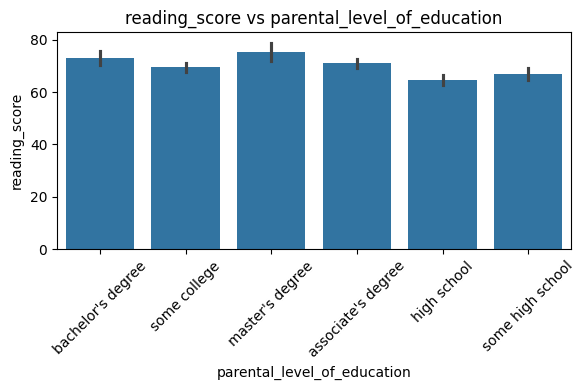

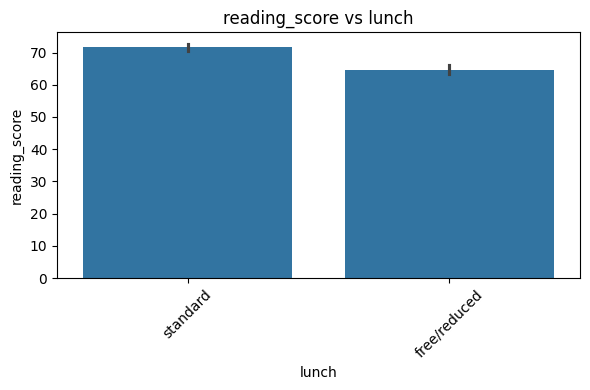

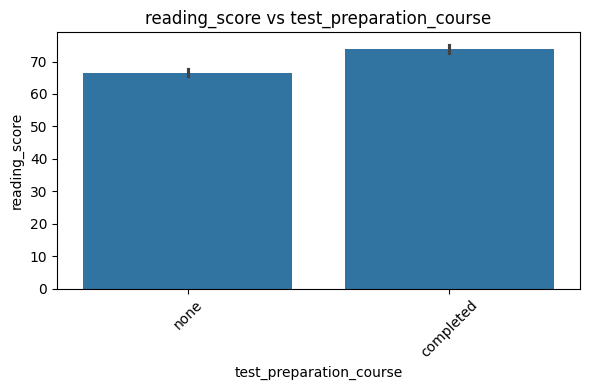

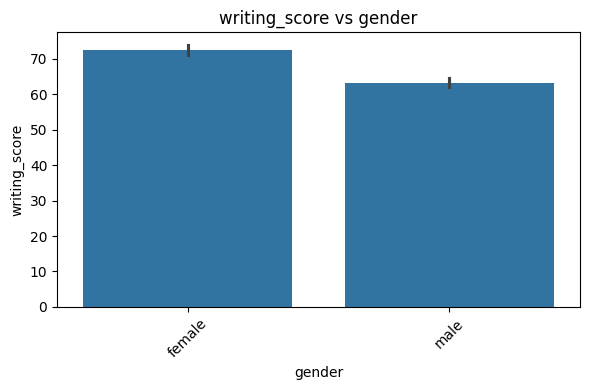

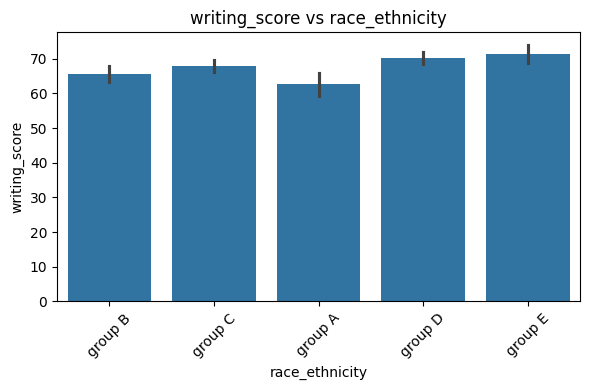

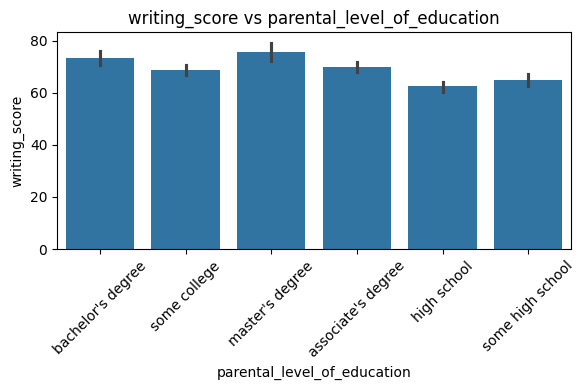

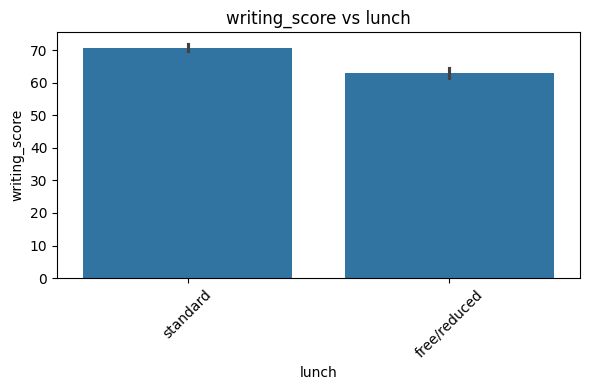

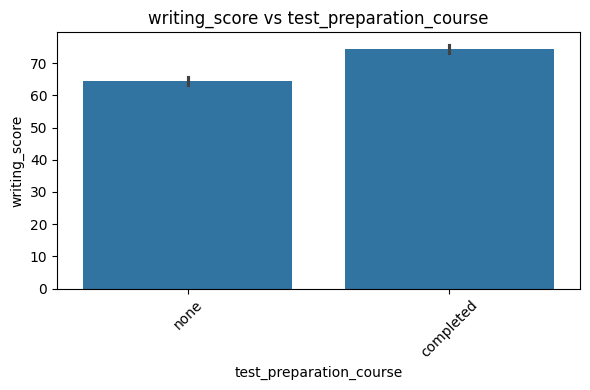

In [80]:
## Bar plots

for num in numerical_cols:
    for cat in categorical_cols:
        plt.figure(figsize=(6,4))
        sns.barplot(data=df, x=cat, y=num)
        plt.title(f"{num} vs {cat}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

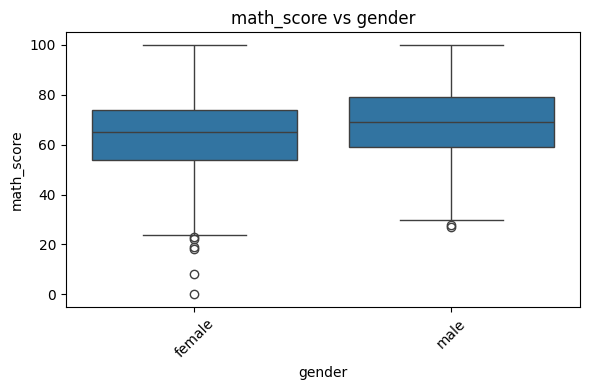

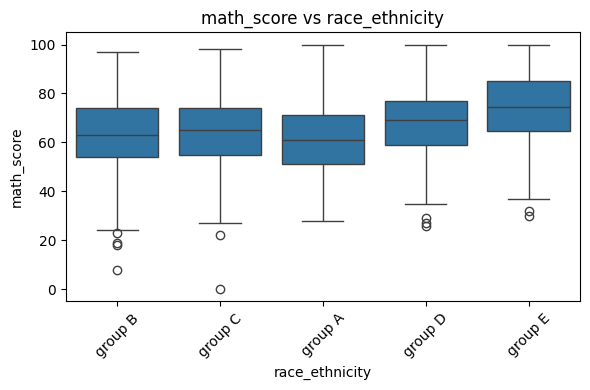

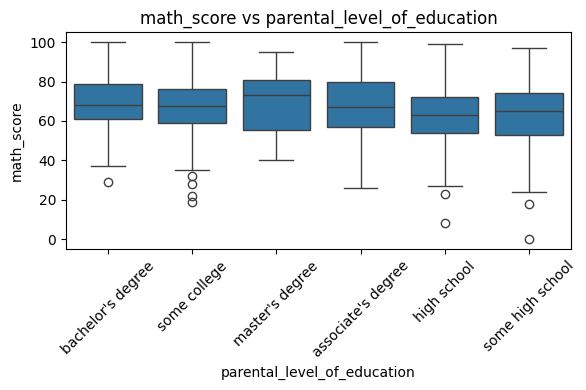

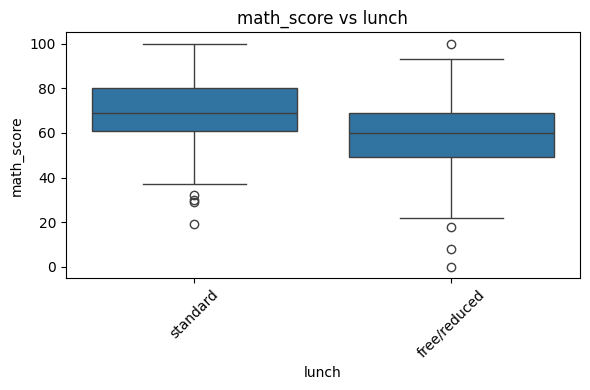

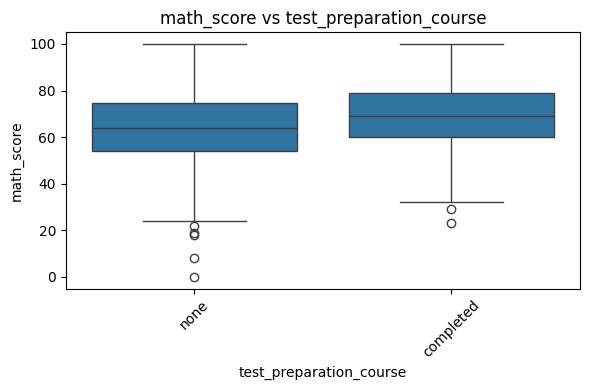

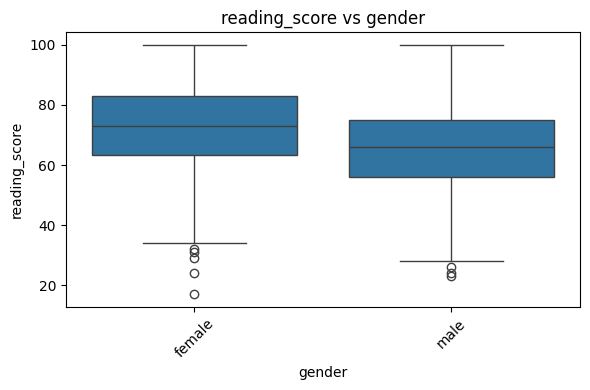

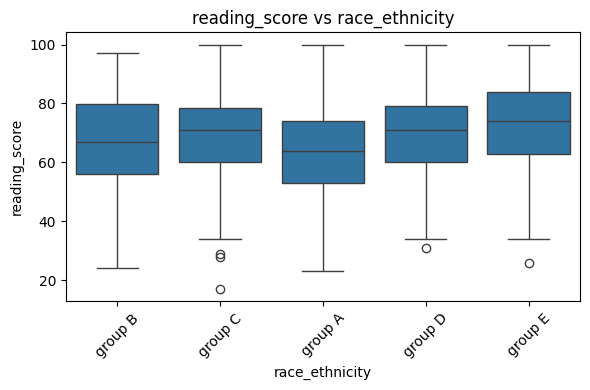

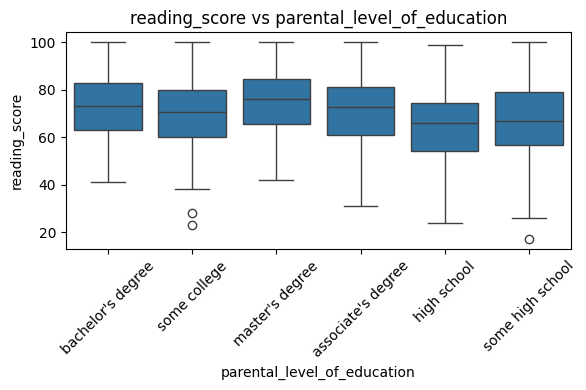

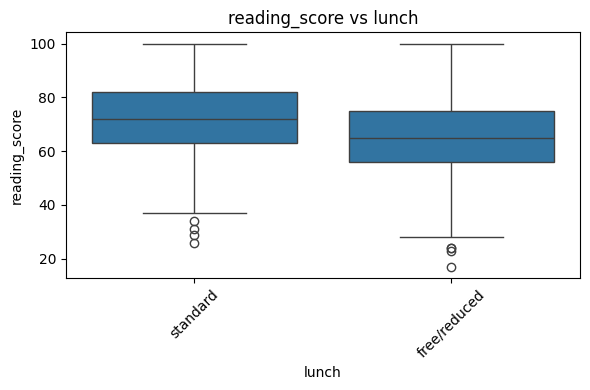

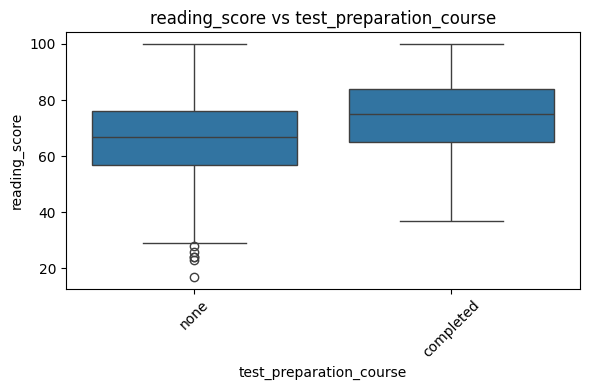

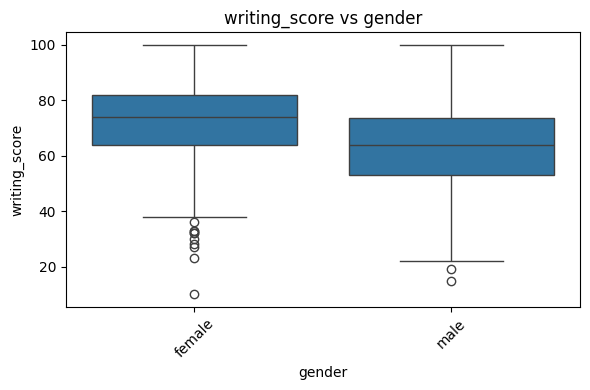

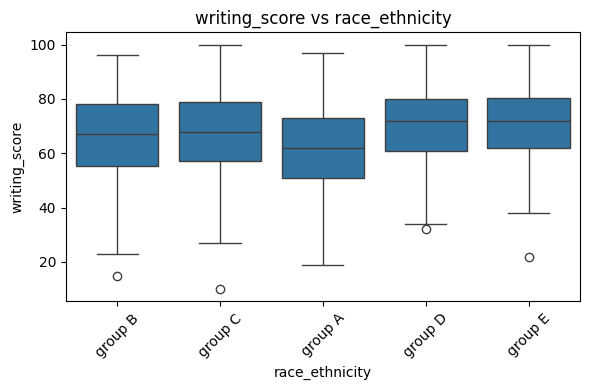

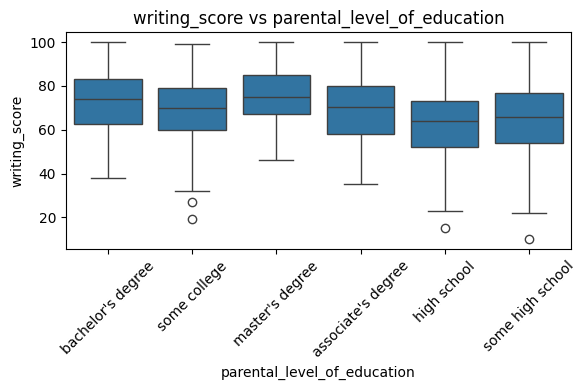

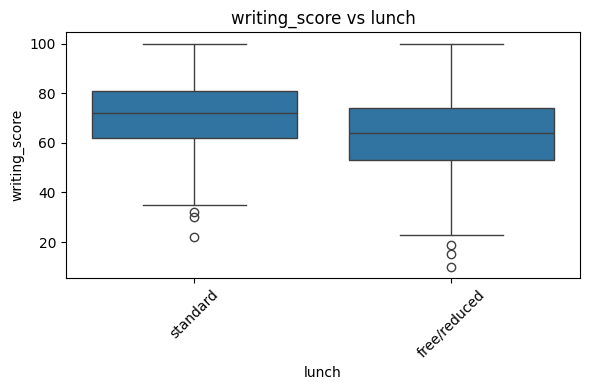

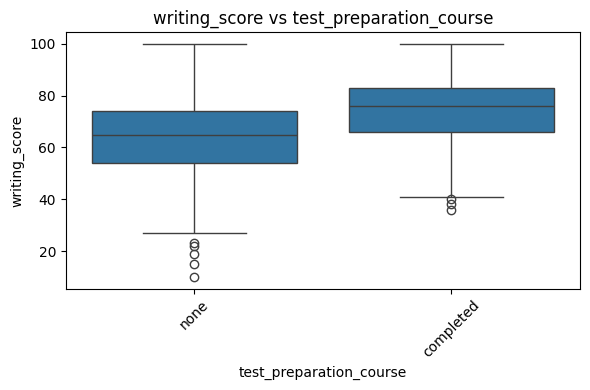

In [81]:
for num in numerical_cols:
    for cat in categorical_cols:
        plt.figure(figsize=(6,4))
        sns.boxplot(data=df, x=cat, y=num)
        plt.title(f"{num} vs {cat}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

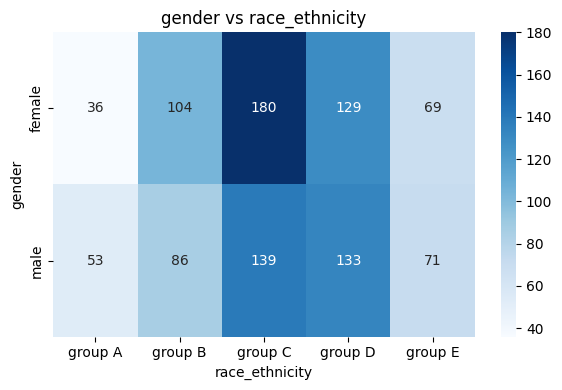

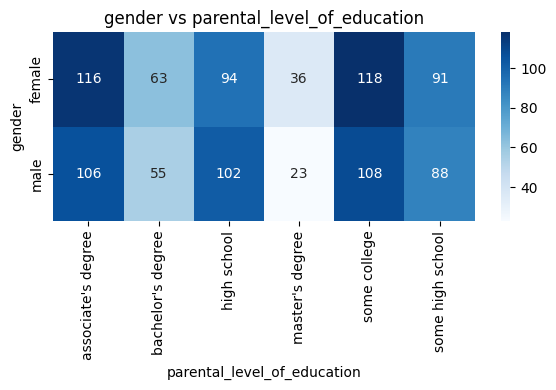

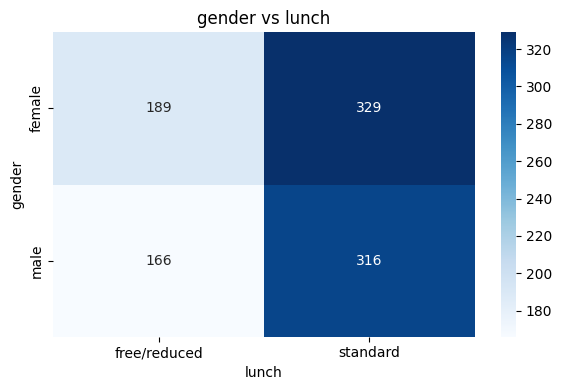

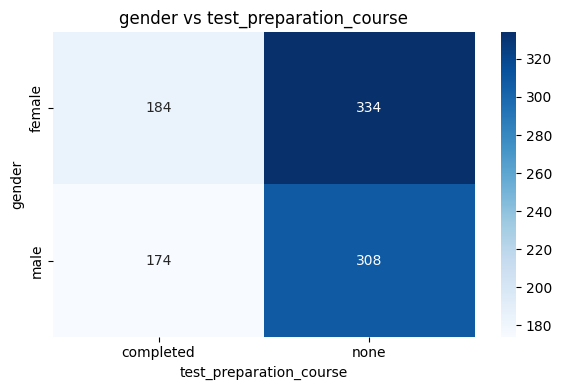

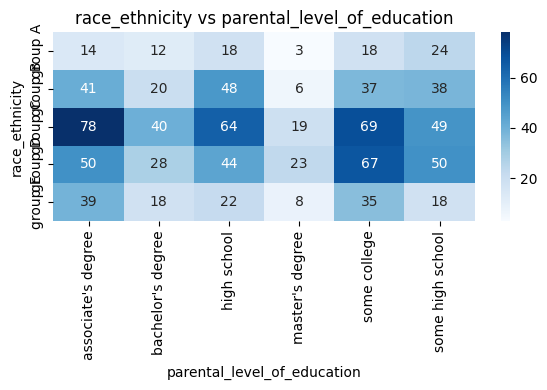

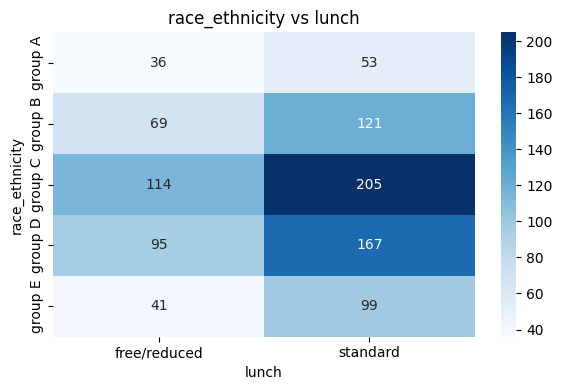

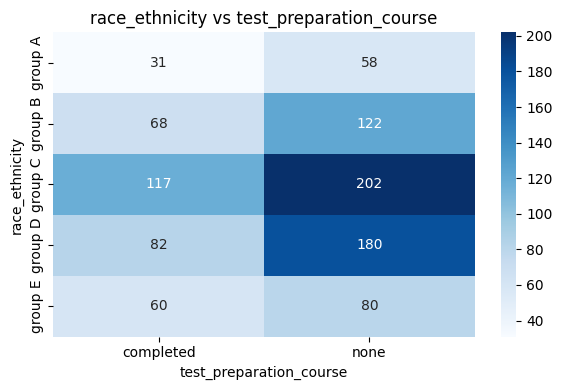

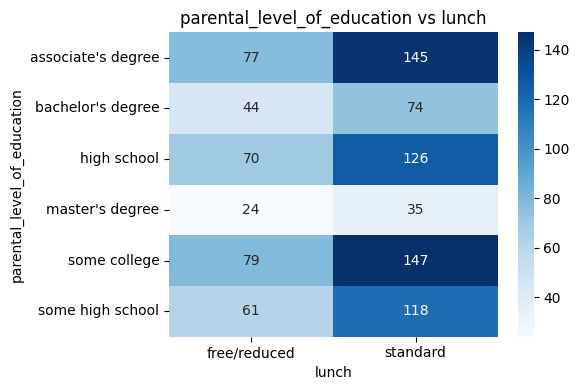

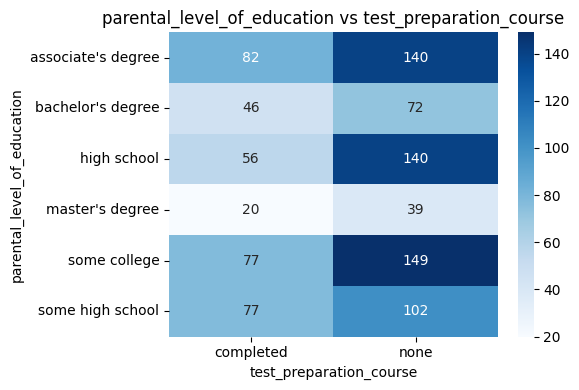

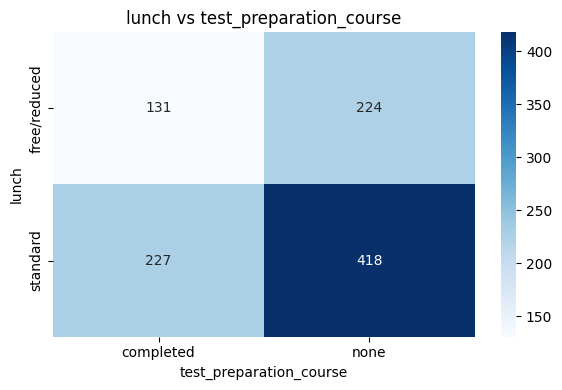

In [82]:
# Heatmaps
for x, y in combinations(categorical_cols, 2):
    plt.figure(figsize=(6, 4))

    table = pd.crosstab(df[x], df[y])

    sns.heatmap(table, annot=True, cmap="Blues", fmt="d")

    plt.title(f"{x} vs {y}")
    plt.tight_layout()
    plt.show()

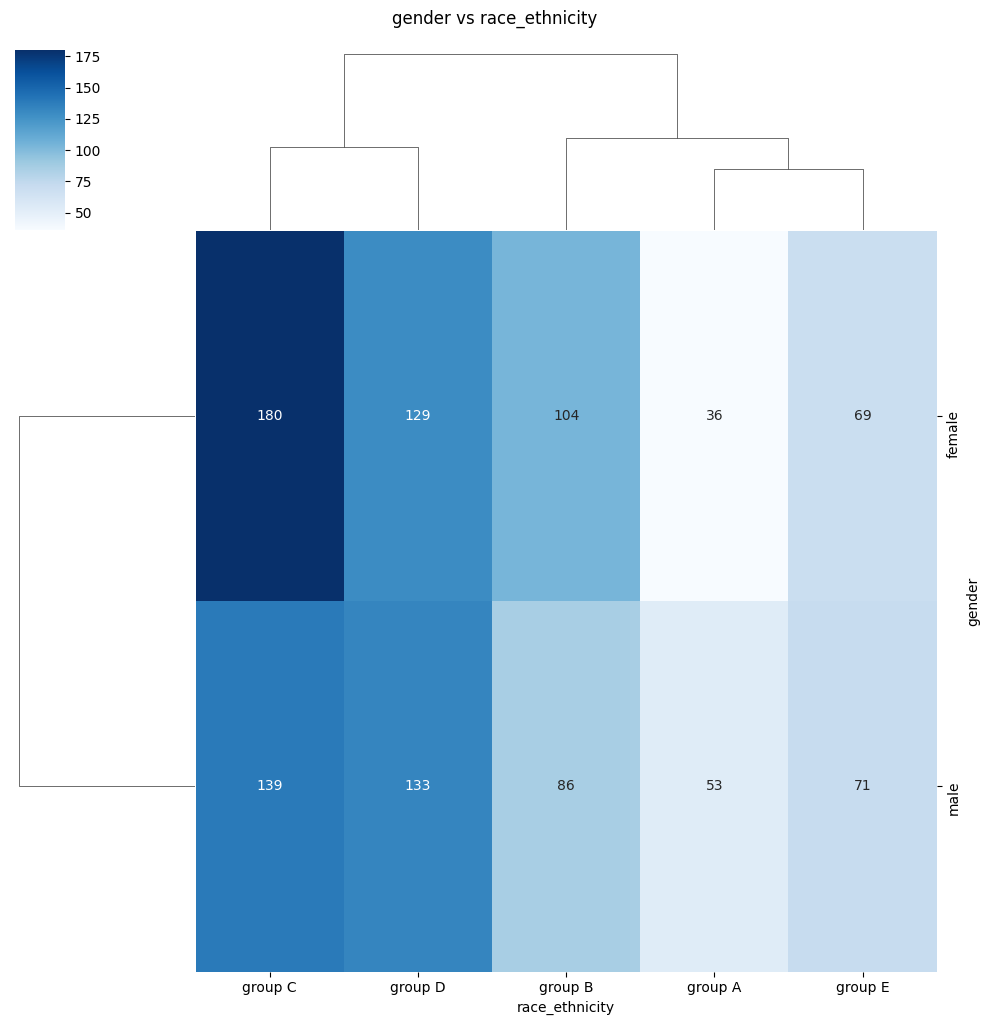

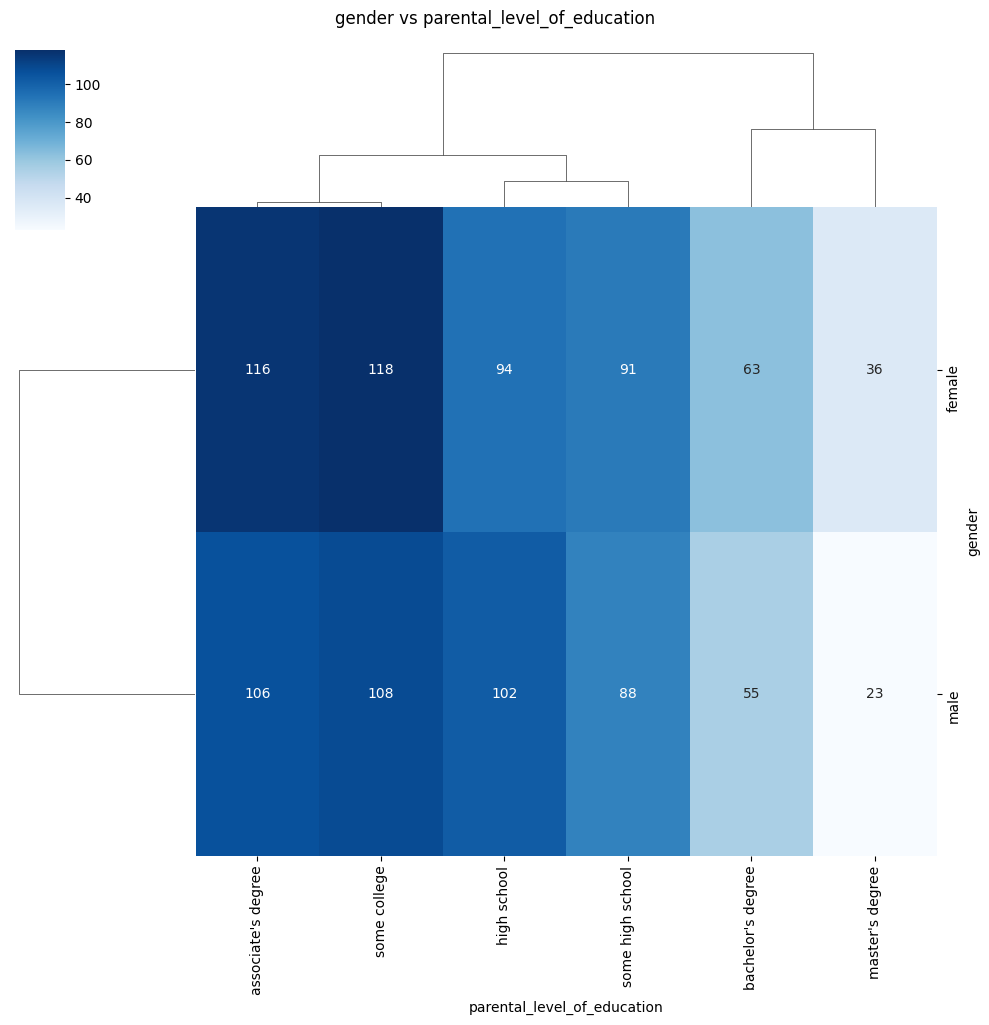

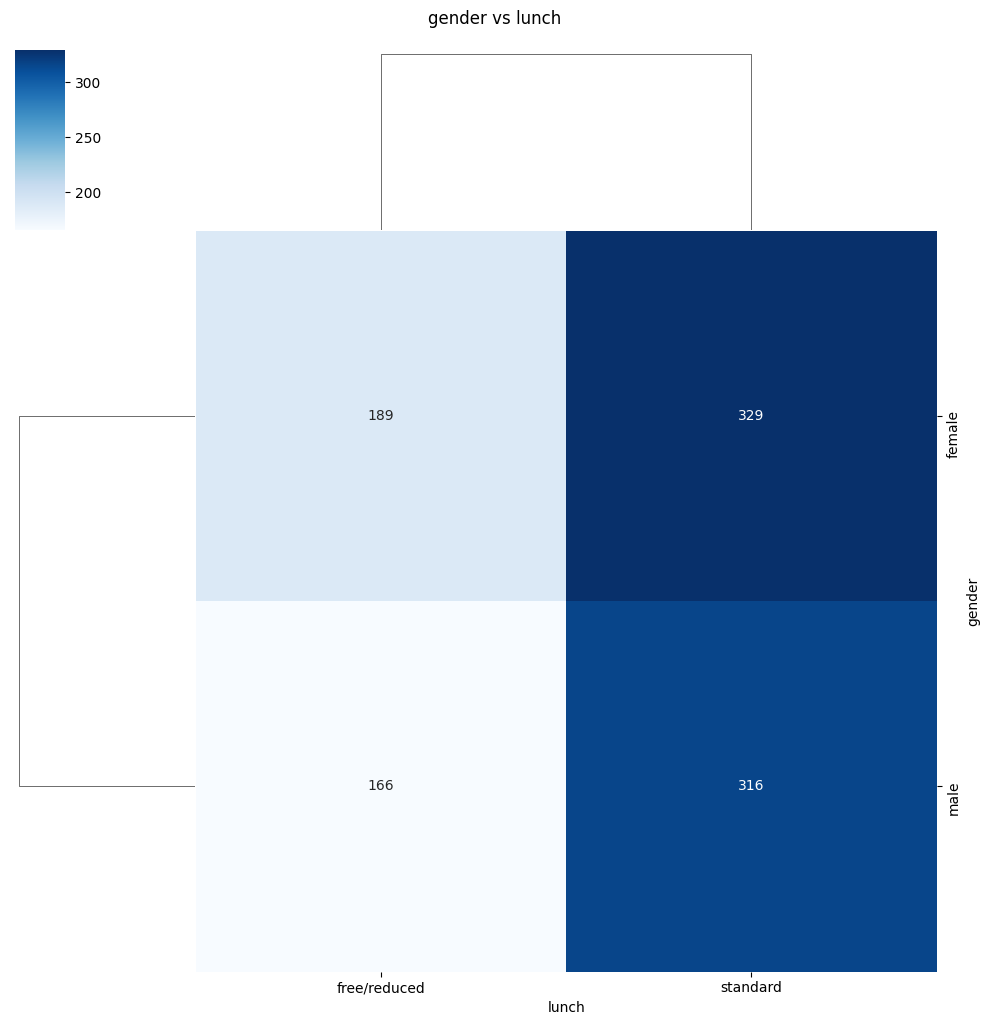

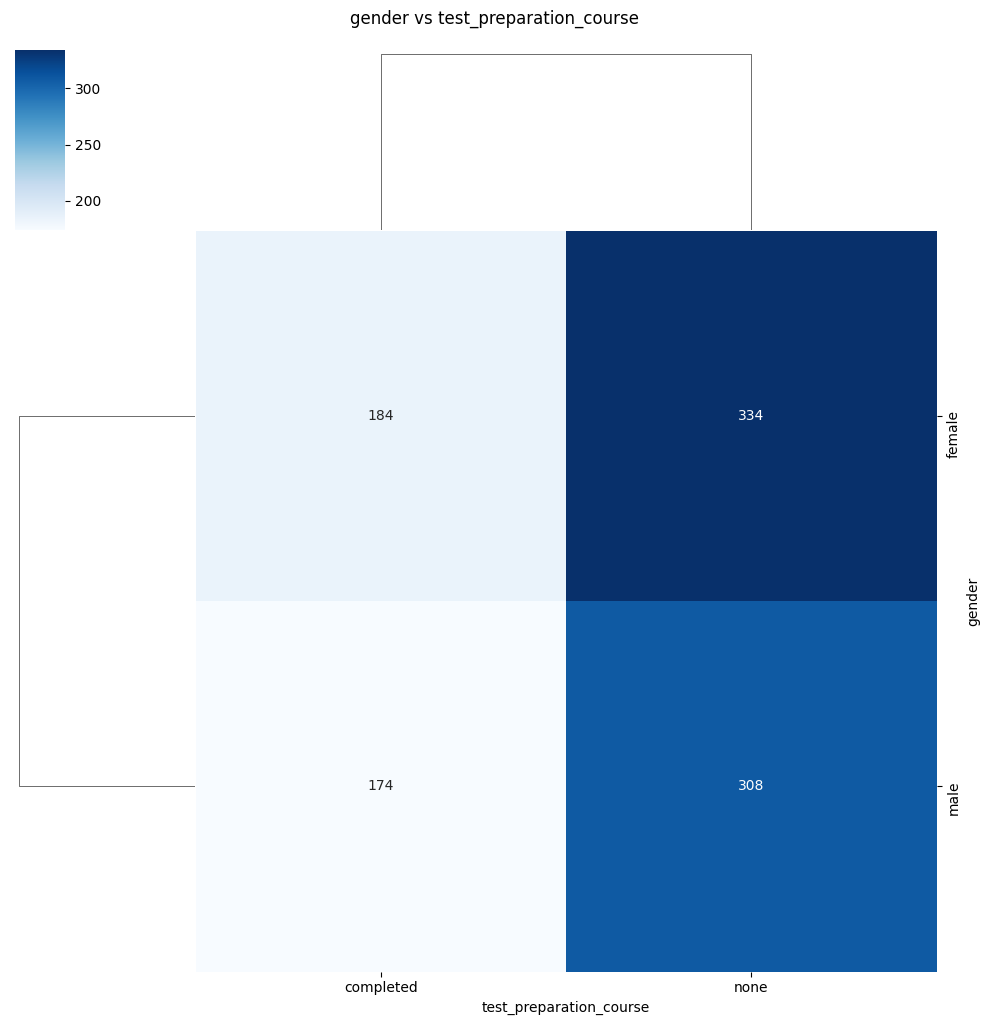

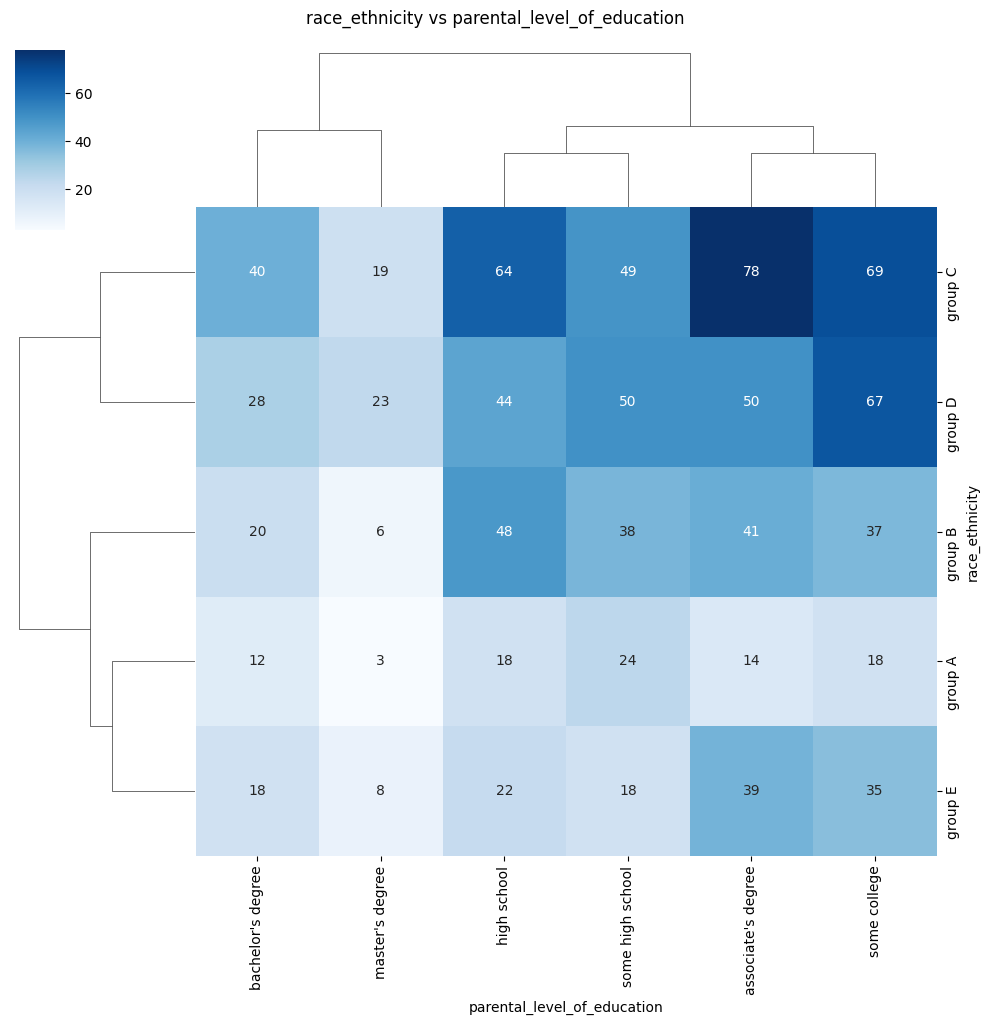

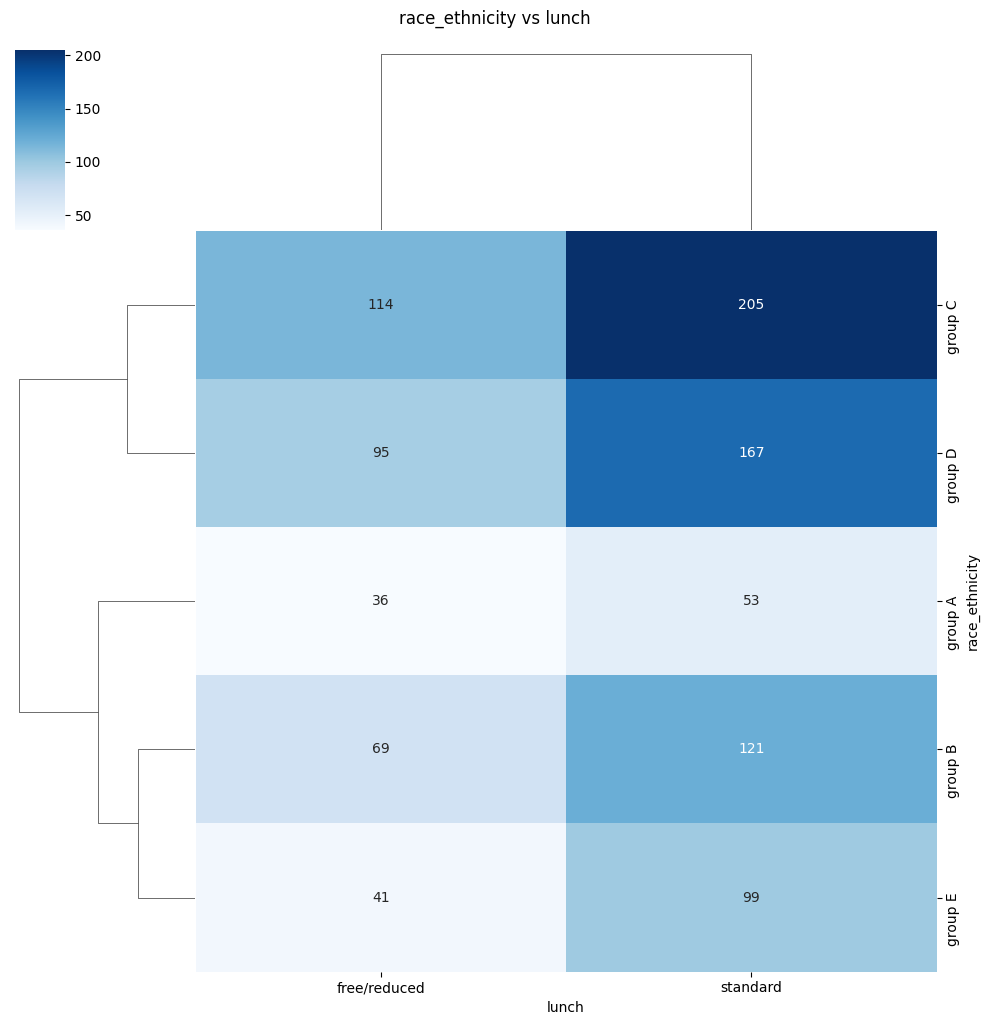

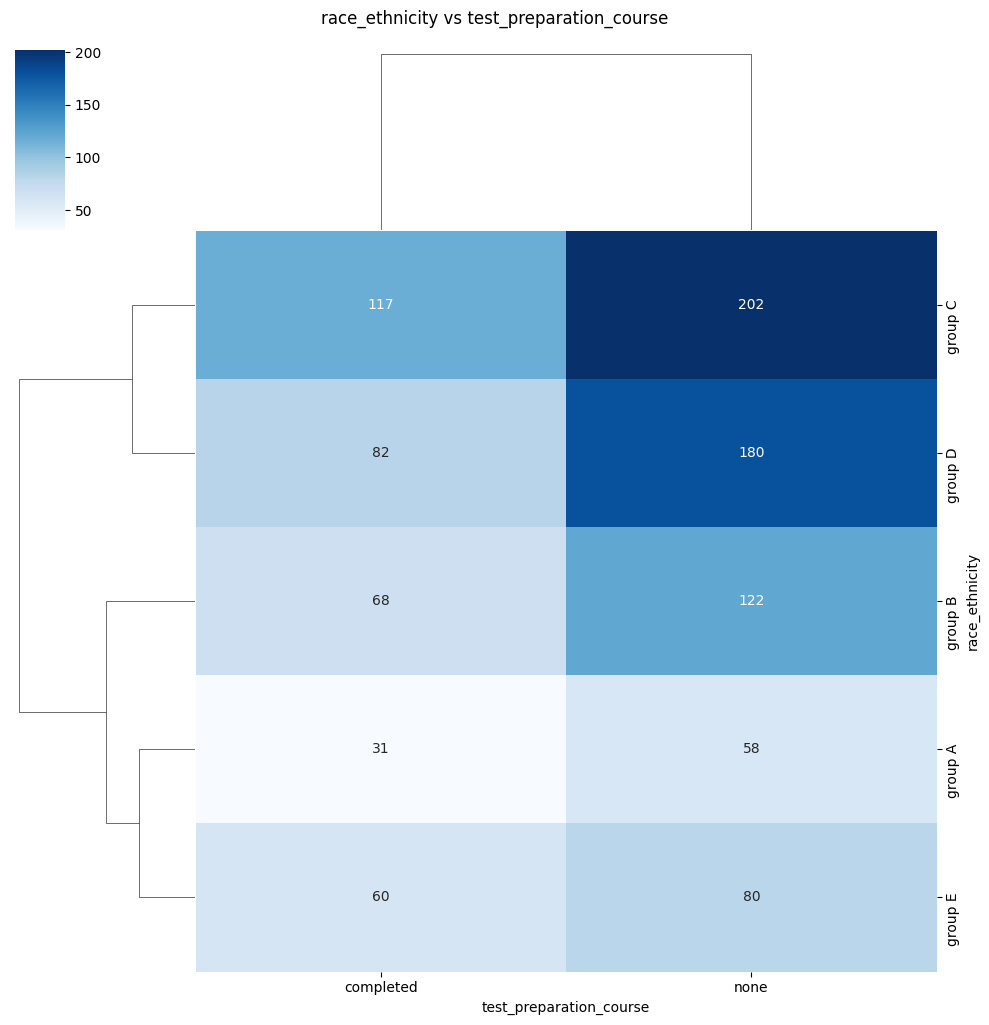

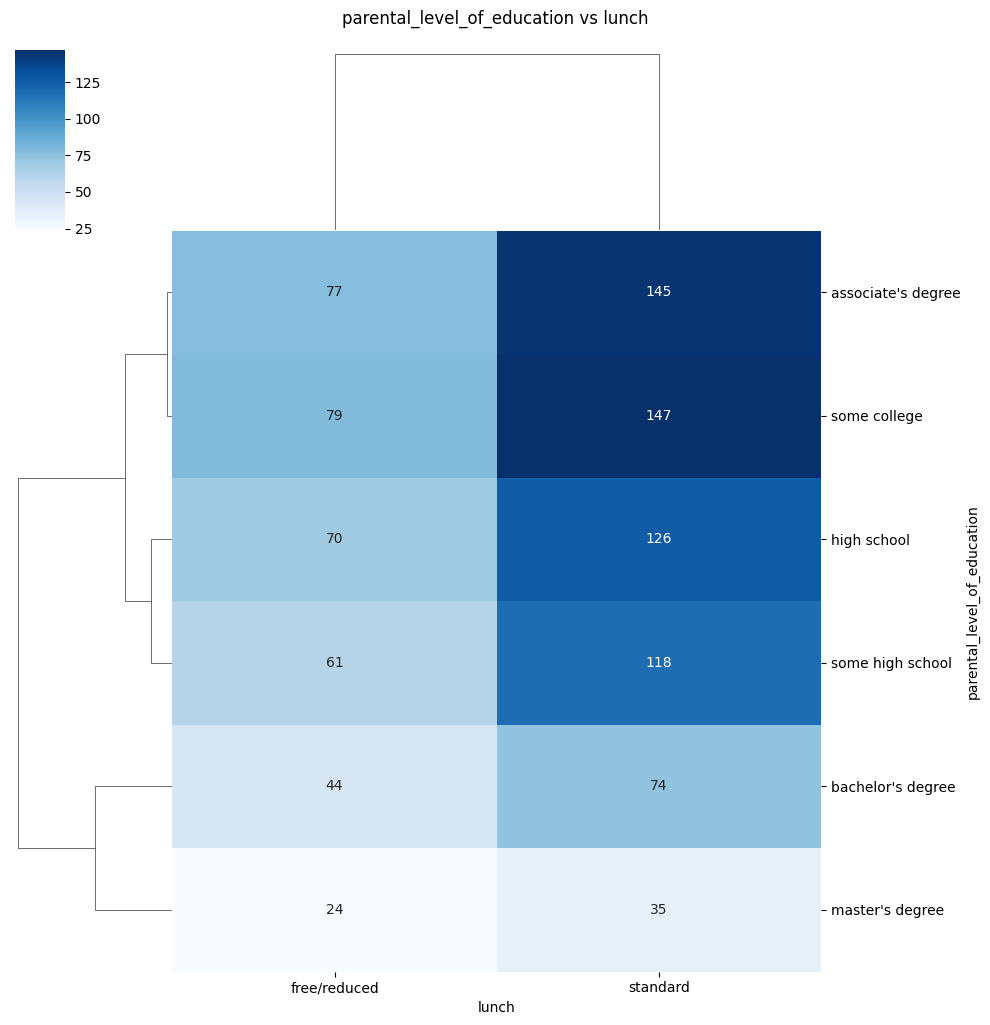

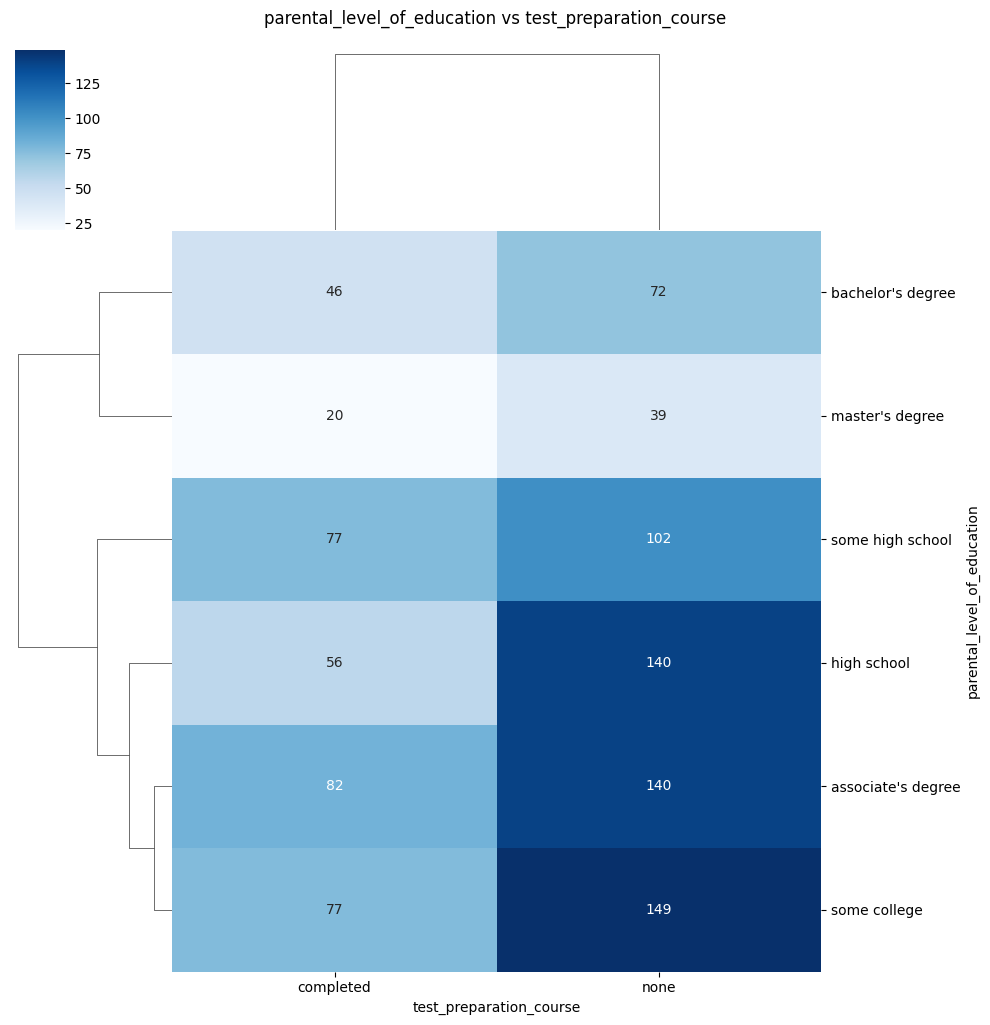

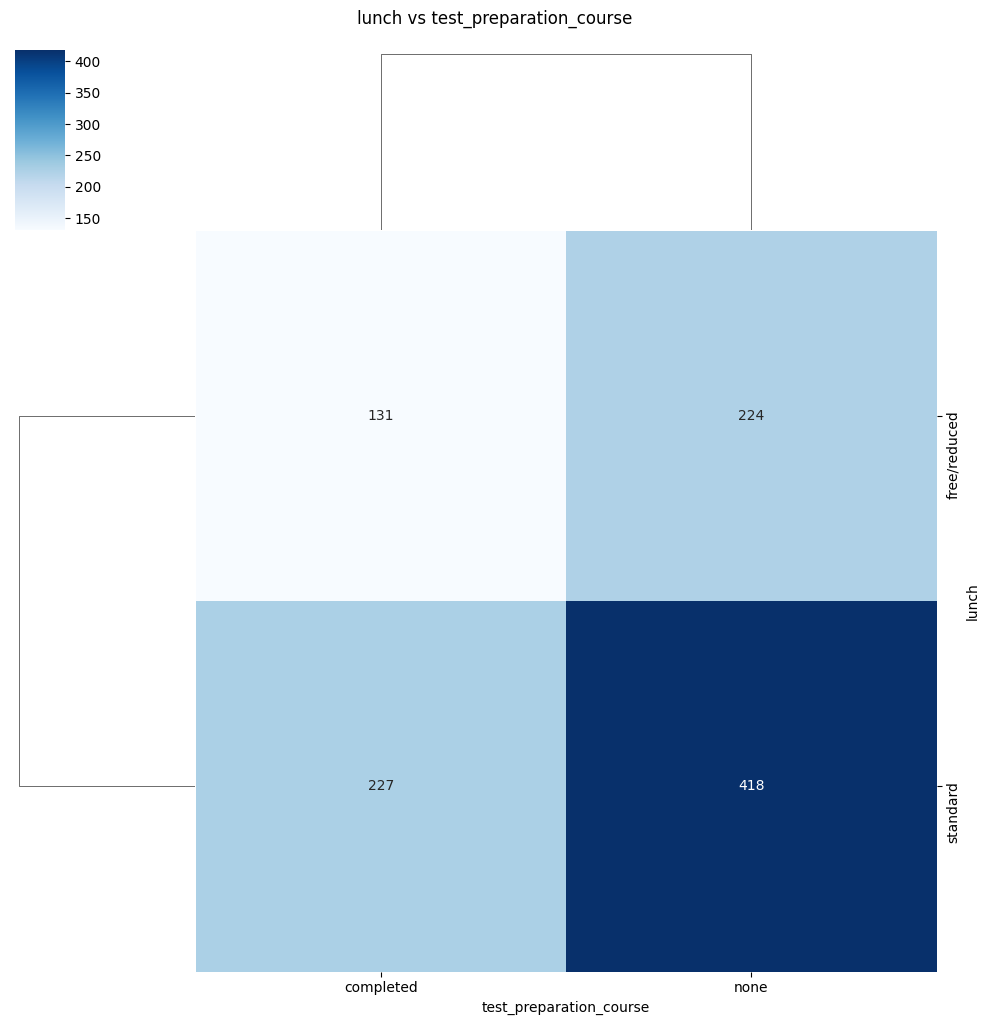

In [83]:
from itertools import combinations
import scipy

for x, y in combinations(categorical_cols, 2):

    table = pd.crosstab(df[x], df[y])

    sns.clustermap(
        table,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.suptitle(f"{x} vs {y}", y=1.02)
    plt.show()

In [84]:
import pandas as pd
from ydata_profiling import ProfileReport

# Create profiling report
profile = ProfileReport(
    df,
    title="EDA Report",
    explorative=True
)

# Save to HTML
profile.to_file("EDA_Report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 119.20it/s]


## Feature Engineering

### Feature Transformation

Finding the distribution of data 

In [85]:
numerical_cols

Index(['math_score', 'reading_score', 'writing_score'], dtype='object')

In [86]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [87]:
# EXAMPLE OF FUNCTION TRANSFORMER:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

# Define a custom function to calculate the square of the input data
def square_func(X):
    return np.square(X)

# Create a function transformer using the custom function
square_transformer = FunctionTransformer(func=square_func)

X = df.drop(columns= ['math_score'])
y = df['math_score']
df[['reading_score', 'writing_score']] = square_transformer.fit_transform(X[['reading_score', 'writing_score']])

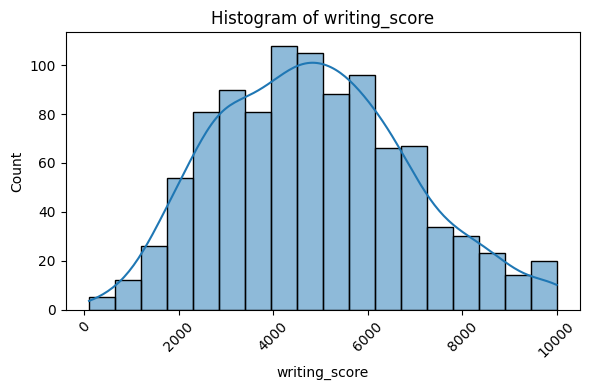

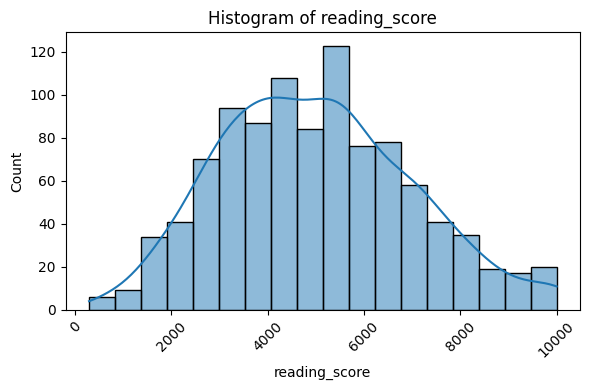

In [88]:
for col in ['writing_score', 'reading_score']:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Handling outliers

In [93]:
df_filtered = df.copy()

for col in numerical_cols:
    lower = df_filtered[col].quantile(0.025)
    upper = df_filtered[col].quantile(0.975)
    df_filtered = df_filtered[(df_filtered[col] >= lower) & (df_filtered[col] <= upper)]

df_filtered.shape

(880, 8)

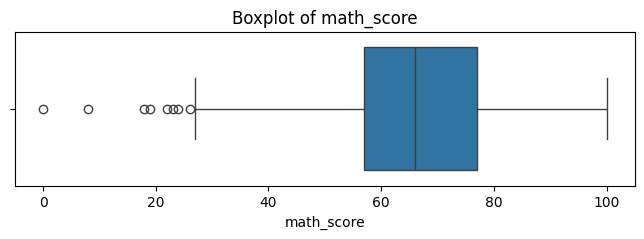

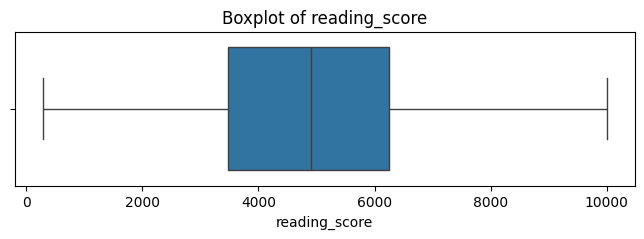

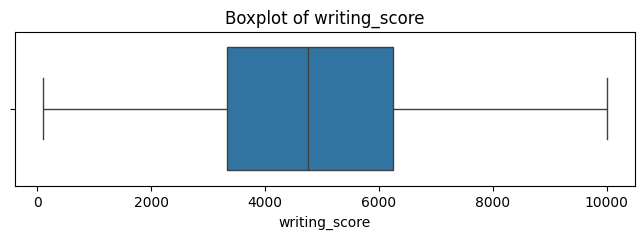

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include="number").columns

for col in numerical_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()